In [95]:
import torch
import torch.nn as nn
from multigrid import DirichletBoundaryCondition, NeumannBoundaryCondition, laplace_jacobi_step, laplace_jacobi_smoothen, poisson_jacobi_smoothen
from multigrid import laplace_multigrid_v_cycle, laplace_multigrid_w_cycle, laplace_multigrid_f_cycle, laplace_full_multigrid_v_cycle, laplace_multigrid_half_v_cycle
from multigrid import poisson_exact_solve, poisson_multigrid, integrate_vf_on_grid
from utils import interpolate, restrict2d, laplace_smoothen, restrict1d, even_pad, conv2d
import time
import matplotlib.pyplot as plt
from ipywidgets import interact

## Updated Laplace interface

In [1]:
n = 256
bc = DirichletBoundaryCondition.empty_w_size(n, n)

bc.bottom[:128] = torch.linspace(13, 5, 128)
bc.bottom[128:192] = 5
bc.bottom[192:] = torch.linspace(5, 13, 64)

bc.top = 21

bc.left[:100] = torch.linspace(13, 40, 100)
bc.left[100:150] = 40
bc.left[150:] = torch.linspace(40, 21, 106)

bc.right[:150] = torch.linspace(13, 40, 150)
bc.right[150:200] = 40
bc.right[200:] = torch.linspace(40, 21, 56)

bc.add_rectangle(50, 50, 40, left=0, bottom=100)
bc.add_rectangle(50, 50, 40, right=-1, top=200)

bc.show()

NameError: name 'DirichletBoundaryCondition' is not defined

Smoothed for 249 iteration(s)
Smoothed for 444 iteration(s)
Smoothed for 500 iterations
Smoothed for 451 iteration(s)
Smoothed for 88 iteration(s)


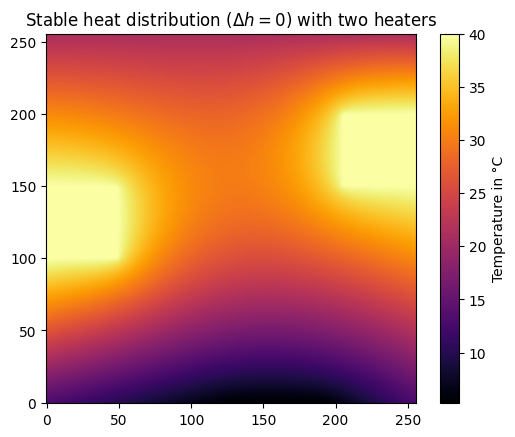

In [ ]:
f_smooth = laplace_multigrid_half_v_cycle(torch.full((256, 256), 22.), bc, depth=4, tol=1e-4, maxiter=500, jacobi_damping_factor=1.)
plt.imshow(f_smooth, cmap='inferno', origin='lower')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with two heaters')
plt.show()

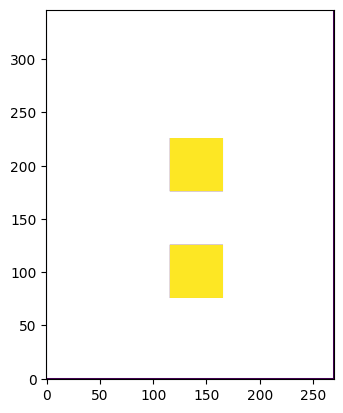

In [36]:
bc = DirichletBoundaryCondition.empty_w_size(345, 268)
bc.left = bc.right = bc.top = bc.bottom = 0
bc.add_rectangle(50, 50, 10, center=(140, 100))
bc.add_rectangle(50, 50, 10, center=(140, 200))
bc.show()

Smoothed for 154 iteration(s)
Smoothed for 200 iterations
Smoothed for 96 iteration(s)
Smoothed for 45 iteration(s)
Smoothed for 4 iteration(s)


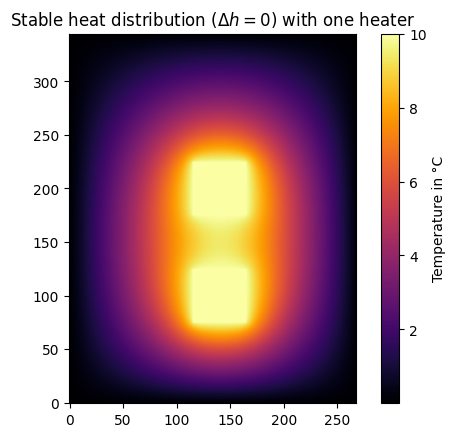

In [40]:
f_smooth = laplace_multigrid_half_v_cycle(torch.full((345, 268), 5.), bc, depth=4, tol=1e-4, maxiter=200, jacobi_damping_factor=1.)
plt.imshow(f_smooth, cmap='inferno', origin='lower')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with one heater')
plt.show()

In [76]:
f = torch.full((256, 256), 22.)
bc_coarse = bc.restrict().restrict().restrict().restrict()
f_coarse = restrict2d(restrict2d(restrict2d(restrict2d(f))))

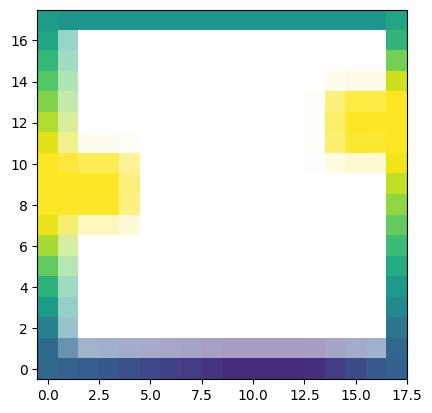

In [77]:
bc_coarse.show()

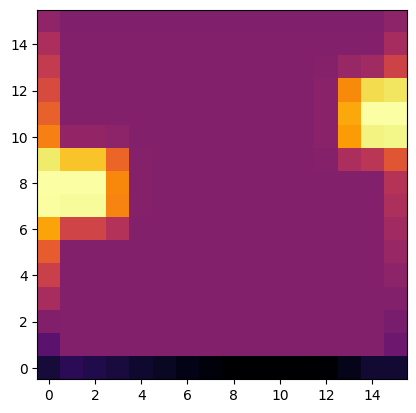

In [62]:
plt.imshow(laplace_jacobi_step(f_coarse, bc_coarse, damping_factor=1.), cmap='inferno', origin='lower')

In [92]:
def compare_smoothing(steps):
    f_smooth_nodamp = f_coarse.clone()
    f_smooth_damp = f_coarse.clone()
    for _ in range(steps):
        f_smooth_nodamp = laplace_jacobi_step(f_smooth_nodamp, bc_coarse, damping_factor=1.)
        f_smooth_damp = laplace_jacobi_step(f_smooth_damp, bc_coarse, damping_factor=2/3)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 5))
    ax1.imshow(f_smooth_nodamp, cmap='inferno', origin='lower')
    ax1.set_title('No damping ($\\omega = 1.0$)')
    ax2.imshow(laplace_jacobi_step(f_smooth_nodamp, bc_coarse) - f_smooth_nodamp, origin='lower', vmin=-.25, vmax=.25)
    ax2.set_title('No damping - Residual')
    ax3.imshow(f_smooth_damp, cmap='inferno', origin='lower')
    ax3.set_title('With damping ($\\omega = 2/3$)')
    ax4.imshow(laplace_jacobi_step(f_smooth_damp, bc_coarse) - f_smooth_damp, origin='lower', vmin=-.25, vmax=.25)
    ax4.set_title('With damping - Residual')
    plt.show()

In [93]:
interact(compare_smoothing, steps=(1, 50, 1))

interactive(children=(IntSlider(value=25, description='steps', max=50, min=1), Output()), _dom_classes=('widge…

<function __main__.compare_smoothing(steps)>

In [ ]:
smooth_coarse = laplace_jacobi_smoothen(f_coarse, bc_coarse, tol=1e-4, damping_factor=1., maxiter=1000)

Smoothed for 338 iteration(s)


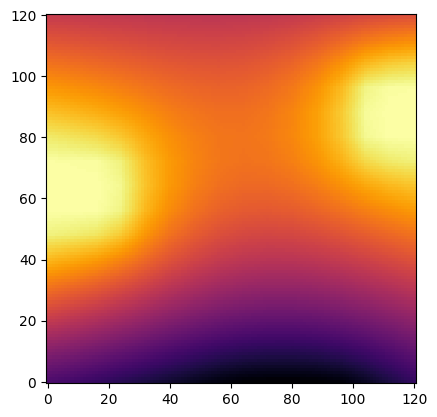

In [57]:
plt.imshow(interpolate(interpolate(interpolate(smooth_coarse))), origin='lower', cmap='inferno')